# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  

**`Student Name`:**  Eshan Srirambhatla

**`Roll Number`:**  U20230126

**`GitHub Branch`:** eshan_U20230126

# Imports and Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from rlcmab_sampler import sampler


# Load Datasets

In [26]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [27]:
drop_cols = ['user_id', 'browser_version']
train_users = train_users.drop(columns=drop_cols)
test_users = test_users.drop(columns=drop_cols)

train_users.columns = train_users.columns.str.strip()
test_users.columns = test_users.columns.str.strip()

train_users['age'] = train_users['age'].fillna(train_users['age'].mean())
test_users['age'] = test_users['age'].fillna(test_users['age'].mean())
train_users = train_users.fillna(0)
test_users = test_users.fillna(0)

le_r = LabelEncoder()
all_regions = pd.concat([train_users['region_code'], test_users['region_code']], axis=0).astype(str)
le_r.fit(all_regions)
train_users['region_code'] = le_r.transform(train_users['region_code'].astype(str))
test_users['region_code'] = le_r.transform(test_users['region_code'].astype(str))

train_users['subscriber'] = train_users['subscriber'].astype(int)
test_users['subscriber'] = test_users['subscriber'].astype(int)

le_u = LabelEncoder()
train_users['label_encoded'] = le_u.fit_transform(train_users['label'])

print("Feature Columns:", list(train_users.drop(columns=['label', 'label_encoded']).columns))
print(f"Target Labels Mapping: {dict(zip(le_u.classes_, le_u.transform(le_u.classes_)))}")

X = train_users.drop(columns=['label', 'label_encoded'])
y = train_users['label_encoded']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


Feature Columns: ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']
Target Labels Mapping: {'user_1': np.int64(0), 'user_2': np.int64(1), 'user_3': np.int64(2)}


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [28]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_val)
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb, target_names=le_u.classes_))
accuracy_xgb = accuracy_score(y_val, y_pred_xgb)
print(f"Validation Accuracy: {accuracy_xgb:.4f}")

XGBoost Classification Report:
              precision    recall  f1-score   support

      user_1       0.88      0.82      0.85       147
      user_2       0.96      0.89      0.92       141
      user_3       0.79      0.94      0.86       112

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.87       400
weighted avg       0.88      0.88      0.88       400

Validation Accuracy: 0.8750


# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [29]:
def getArmIndex(user_context_idx, news_category):
    category_to_idx = {
        'Entertainment': 0,
        'Education': 1,
        'Tech': 2,
        'Crime': 3
    }

    category_idx = category_to_idx[news_category]
    arm_idx = user_context_idx * 4 + category_idx
    return arm_idx

def getCategoryArm(arm_idx):
    user_context_idx = arm_idx//4
    category_idx = arm_idx%4

    idx_to_category = {0: 'Entertainment', 1: 'Education', 2: 'Tech', 3: 'Crime'}
    idx_to_user = {0: 'user_1', 1: 'user_2', 2: 'user_3'}
    
    return idx_to_user[user_context_idx], idx_to_category[category_idx]

for j in range(12):
    user, cat = getCategoryArm(j)
    print(f"Arm {j}: ({cat}, {user})")

Arm 0: (Entertainment, user_1)
Arm 1: (Education, user_1)
Arm 2: (Tech, user_1)
Arm 3: (Crime, user_1)
Arm 4: (Entertainment, user_2)
Arm 5: (Education, user_2)
Arm 6: (Tech, user_2)
Arm 7: (Crime, user_2)
Arm 8: (Entertainment, user_3)
Arm 9: (Education, user_3)
Arm 10: (Tech, user_3)
Arm 11: (Crime, user_3)


In [30]:
ROLL_NUMBER = 126

rewardSampler = sampler(ROLL_NUMBER)

for j in range(12):
    user, cat = getCategoryArm(j)
    test_reward = rewardSampler.sample(j)
    print(f"Arm {j} ({cat}, {user}): {test_reward:.4f}")

Arm 0 (Entertainment, user_1): 1.8432
Arm 1 (Education, user_1): -6.4039
Arm 2 (Tech, user_1): -4.8358
Arm 3 (Crime, user_1): 5.0394
Arm 4 (Entertainment, user_2): -7.3349
Arm 5 (Education, user_2): 0.2614
Arm 6 (Tech, user_2): 0.7131
Arm 7 (Crime, user_2): 4.9501
Arm 8 (Entertainment, user_3): -4.8547
Arm 9 (Education, user_3): -0.3978
Arm 10 (Tech, user_3): 6.9313
Arm 11 (Crime, user_3): -1.4099


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [31]:
class EpsilonGreedy:
    def __init__(self, n_arms, epsilon, sampler):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.sampler = sampler
        self.counts = np.zeros(n_arms) 
        self.values = np.zeros(n_arms) 
        self.rewards_history = []

    
    def selectArm(self, context_arms):
        if np.random.random() < self.epsilon:
            return np.random.choice(context_arms)
        

        else:
            contextValues = [self.values[arm] for arm in context_arms]
            best_idx = np.argmax(contextValues)
            return context_arms[best_idx]
        
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        cumulativeRewards = []
        total_reward = 0
        
        for t in range(T):
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            context_arms = list(range(context_idx * 4, (context_idx + 1) * 4))
            
            chosen_arm = self.selectArm(context_arms)
            
            reward = self.sampler.sample(chosen_arm)
            
            # Update
            self.update(chosen_arm, reward)
            total_reward += reward
            cumulativeRewards.append(total_reward / (t + 1))
        
        return cumulativeRewards


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [32]:
class UCB:
    def __init__(self, n_arms, c, sampler):
        self.n_arms = n_arms
        self.c = c
        self.sampler = sampler
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.rewards_history = []
        self.total_counts = 0
        
    def select_arm(self, context_arms):
        for arm in context_arms:
            if self.counts[arm] == 0:
                return arm
        
        ucbValues = []
        for arm in context_arms:
            avg_reward = self.values[arm]
            exploration_bonus = self.c * np.sqrt(
                np.log(self.total_counts + 1) / self.counts[arm]
            )
            ucbValues.append(avg_reward + exploration_bonus)
        
        best_idx = np.argmax(ucbValues)
        return context_arms[best_idx]
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        self.total_counts += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        cumulativeRewards = []
        total_reward = 0
        
        for t in range(T):
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            contextArms = list(range(context_idx * 4, (context_idx + 1) * 4))
            chosen_arm = self.select_arm(contextArms)
            reward = self.sampler.sample(chosen_arm)
            
            self.update(chosen_arm, reward)
            total_reward += reward
            cumulativeRewards.append(total_reward / (t + 1))
        
        return cumulativeRewards

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [33]:
class SoftMax:
    def __init__(self, n_arms, tau, sampler):
        self.n_arms = n_arms
        self.tau = tau  
        self.sampler = sampler
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.rewards_history = []

    def select_arm(self, context_arms):
        contextValues = np.array([self.values[arm] for arm in context_arms])
    
        exp_values = np.exp(contextValues / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        chosen_idx = np.random.choice(len(context_arms), p=probabilities)
        return context_arms[chosen_idx]
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n
        self.rewards_history.append(reward)
    
    def run_simulation(self, T, context_distribution):
        cumulativeRewards = []
        totalReward = 0
        
        for t in range(T):
            context_idx = np.random.choice(
                list(context_distribution.keys()),
                p=list(context_distribution.values())
            )
            
            context_arms = list(range(context_idx * 4, (context_idx + 1) * 4))
            chosen_arm = self.select_arm(context_arms)
            reward = self.sampler.sample(chosen_arm)
            
            self.update(chosen_arm, reward)
            totalReward += reward
            cumulativeRewards.append(totalReward / (t + 1))
        
        return cumulativeRewards

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [34]:
T = 10000
nArms = 12

contextDistribution = {0: 1/3, 1: 1/3, 2: 1/3}
epsilonValues = [0.01, 0.1, 0.3]
eg_results = {}

print("Epsilon-Greedy simulations")
for eps in epsilonValues:
    print(f"  Epsilon = {eps}")
    eg = EpsilonGreedy(nArms, eps, rewardSampler)
    cumulativeRewards = eg.run_simulation(T, contextDistribution)
    eg_results[eps] = {
        'cumulative_rewards': cumulativeRewards,
        'model': eg
    }

c_values = [0.5, 1.0, 2.0]
ucbResults = {}

print("UCB simulations")
for c in c_values:
    print(f"  C = {c}")
    ucb = UCB(nArms, c, rewardSampler)
    cumulativeRewards = ucb.run_simulation(T, contextDistribution)
    ucbResults[c] = {
        'cumulative_rewards': cumulativeRewards,
        'model': ucb
    }

# SoftMax with tau = 1
tau = 1.0
print(f"\nRunning SoftMax simulation (tau = {tau})...")
softmax = SoftMax(nArms, tau, rewardSampler)
softmax_cumulative_rewards = softmax.run_simulation(T, contextDistribution)


Epsilon-Greedy simulations
  Epsilon = 0.01
  Epsilon = 0.1
  Epsilon = 0.3
UCB simulations
  C = 0.5
  C = 1.0
  C = 2.0

Running SoftMax simulation (tau = 1.0)...


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


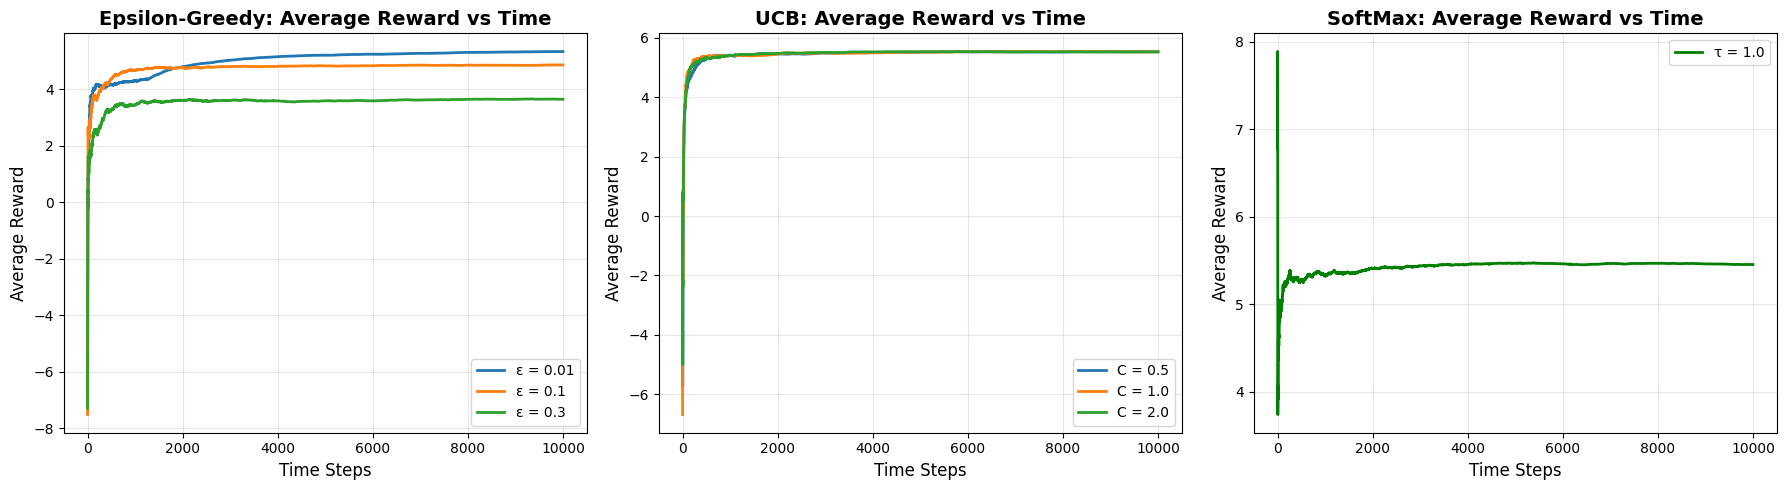

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
for eps in epsilonValues:
    rewards = eg_results[eps]['cumulative_rewards']
    ax.plot(rewards, label=f'ε = {eps}', linewidth=2)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Average Reward vs Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for c in c_values:
    rewards = ucbResults[c]['cumulative_rewards']
    ax.plot(rewards, label=f'C = {c}', linewidth=2)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('UCB: Average Reward vs Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# SoftMax
ax = axes[2]
ax.plot(softmax_cumulative_rewards, label=f'τ = {tau}', linewidth=2, color='green')
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('SoftMax: Average Reward vs Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


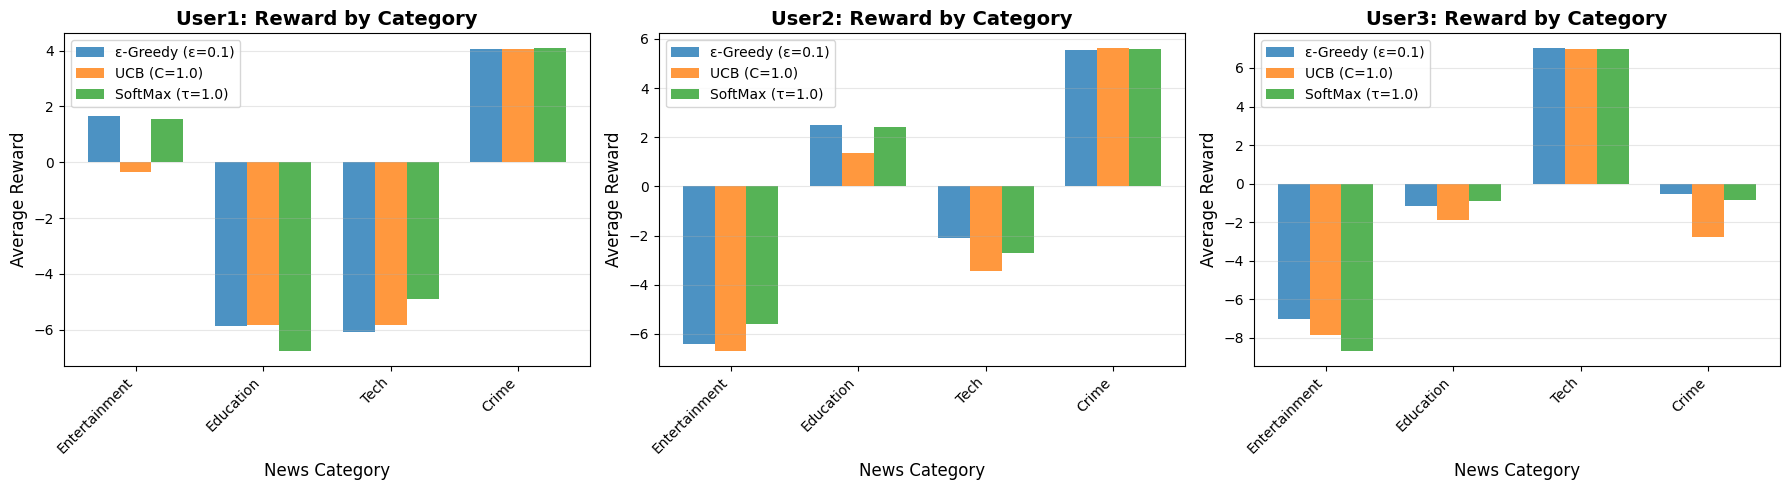

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
context_names = ['User1', 'User2', 'User3']
categories = ['Entertainment', 'Education', 'Tech', 'Crime']

for ctx_idx, ax in enumerate(axes):
    context_arms = range(ctx_idx * 4, (ctx_idx + 1) * 4)
    best_eps = 0.1
    eg_values = [eg_results[best_eps]['model'].values[arm] for arm in context_arms]
    
    # UCB (best C)
    best_c = 1.0
    ucb_values = [ucbResults[best_c]['model'].values[arm] for arm in context_arms]
    
    softmax_values = [softmax.values[arm] for arm in context_arms]
    
    x = np.arange(len(categories))
    width = 0.25
    
    ax.bar(x - width, eg_values, width, label=f'ε-Greedy (ε={best_eps})', alpha=0.8)
    ax.bar(x, ucb_values, width, label=f'UCB (C={best_c})', alpha=0.8)
    ax.bar(x + width, softmax_values, width, label=f'SoftMax (τ={tau})', alpha=0.8)
    
    ax.set_xlabel('News Category', fontsize=12)
    ax.set_ylabel('Average Reward', fontsize=12)
    ax.set_title(f'{context_names[ctx_idx]}: Reward by Category', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


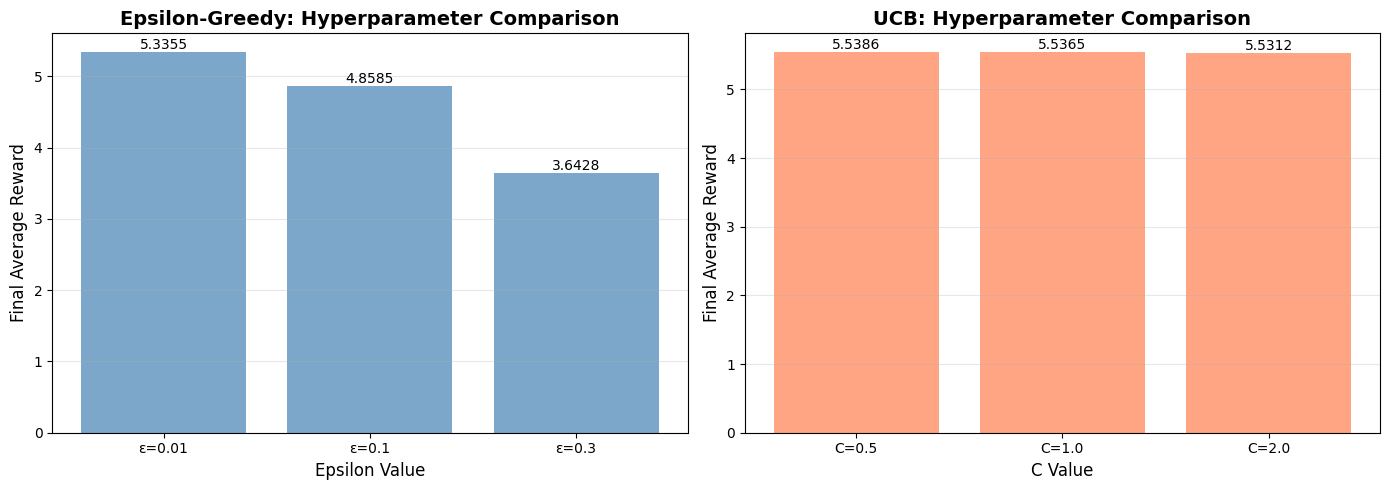

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
final_rewards_eps = [eg_results[eps]['cumulative_rewards'][-1] for eps in epsilonValues]
bars = ax.bar([f'ε={eps}' for eps in epsilonValues], final_rewards_eps, color='steelblue', alpha=0.7)
ax.set_xlabel('Epsilon Value', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# C comparison
ax = axes[1]
final_rewards_c = [ucbResults[c]['cumulative_rewards'][-1] for c in c_values]
bars = ax.bar([f'C={c}' for c in c_values], final_rewards_c, color='coral', alpha=0.7)
ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Final Average Reward', fontsize=12)
ax.set_title('UCB: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


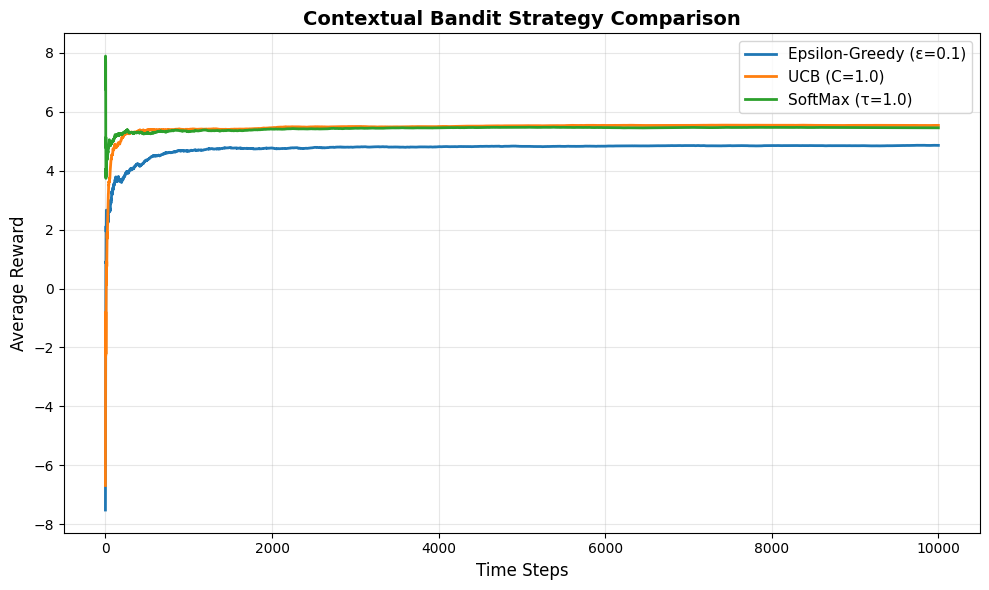

FINAL PERFORMANCE COMPARISON

Epsilon-Greedy (ε=0.1):
  Final Average Reward: 4.8585

UCB (C=1.0):
  Final Average Reward: 5.5365

SoftMax (τ=1.0):
  Final Average Reward: 5.4544


In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
best_eps = 0.1
best_c = 1.0

ax.plot(eg_results[best_eps]['cumulative_rewards'], 
        label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2)
ax.plot(ucbResults[best_c]['cumulative_rewards'], 
        label=f'UCB (C={best_c})', linewidth=2)
ax.plot(softmax_cumulative_rewards, 
        label=f'SoftMax (τ={tau})', linewidth=2)

ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Average Reward', fontsize=12)
ax.set_title('Contextual Bandit Strategy Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("FINAL PERFORMANCE COMPARISON")
print(f"\nEpsilon-Greedy (ε={best_eps}):")
print(f"  Final Average Reward: {eg_results[best_eps]['cumulative_rewards'][-1]:.4f}")

print(f"\nUCB (C={best_c}):")
print(f"  Final Average Reward: {ucbResults[best_c]['cumulative_rewards'][-1]:.4f}")

print(f"\nSoftMax (τ={tau}):")
print(f"  Final Average Reward: {softmax_cumulative_rewards[-1]:.4f}")

In [42]:
# Define feature columns - must match what was used for training the classifier
# The classifier was trained on X = train_users.drop(columns=['label', 'label_encoded'])
# So feature_cols should include all columns except 'label' and 'label_encoded'
feature_cols = [col for col in train_users.columns 
                if col not in ['label', 'label_encoded']]

class NewsRecommendationSystem:
    def __init__(self, classifier, bandit_model, news_df, le_user, feature_cols):
        self.classifier = classifier
        self.bandit_model = bandit_model
        self.news_df = news_df
        self.le_user = le_user
        self.feature_cols = feature_cols
        
    def recommend(self, user_features):
        user_context = self.classifier.predict(user_features[self.feature_cols].values.reshape(1, -1))[0]
        user_label = self.le_user.inverse_transform([user_context])[0]
        
        context_arms = list(range(user_context * 4, (user_context + 1) * 4))
        
        arm_values = [self.bandit_model.values[arm] for arm in context_arms]
        best_arm_idx = np.argmax(arm_values)
        best_arm = context_arms[best_arm_idx]
        _, category = getCategoryArm(best_arm)
        category_articles = self.news_df[self.news_df['category'] == category]
        
        if len(category_articles) > 0:
            recommended_article = category_articles.sample(1).iloc[0]
        else:
            recommended_article = None
        
        return {
            'user_context': user_label,
            'recommended_category': category,
            'arm_index': best_arm,
            'expected_reward': self.bandit_model.values[best_arm],
            'article': recommended_article
        }

# Initialize recommendation system with best model
best_eps = 0.1
recommendation_system = NewsRecommendationSystem(
    classifier=xgb_clf,
    bandit_model=eg_results[best_eps]['model'],
    news_df=news_df,
    le_user=le_u,
    feature_cols=feature_cols
)

In [45]:
all_recommendations = []

for idx in range(len(test_users)):
    user = test_users.iloc[idx]
    recommendation = recommendation_system.recommend(user)
    
    all_recommendations.append({
        'user_index': idx,  # Use index instead of user_id since it was dropped
        'predicted_context': recommendation['user_context'],
        'recommended_category': recommendation['recommended_category'],
        'arm_index': recommendation['arm_index'],
        'expected_reward': recommendation['expected_reward'],
        'article_headline': recommendation['article']['headline'] if recommendation['article'] is not None else 'N/A'
    })

recommendations_df = pd.DataFrame(all_recommendations)

print(f"Generated {len(recommendations_df)} recommendations")
print("\nFirst 10 recommendations:")
print(recommendations_df.head(10))

# Save recommendations
recommendations_df.to_csv('test_user_recommendations.csv', index=False)
print("\nRecommendations saved to 'test_user_recommendations.csv'")

Generated 2000 recommendations

First 10 recommendations:
   user_index predicted_context recommended_category  arm_index  \
0           0            user_2                Crime          7   
1           1            user_1                Crime          3   
2           2            user_1                Crime          3   
3           3            user_1                Crime          3   
4           4            user_1                Crime          3   
5           5            user_3                 Tech         10   
6           6            user_3                 Tech         10   
7           7            user_1                Crime          3   
8           8            user_3                 Tech         10   
9           9            user_3                 Tech         10   

   expected_reward article_headline  
0         5.553247              N/A  
1         4.065891              N/A  
2         4.065891              N/A  
3         4.065891              N/A  
4         4.06

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach




**Epsilon-Greedy** was pretty straightforward and  randomly explores a fixed percentage of the time and exploits the rest. Lower epsilon values (like 0.01) focus more on exploitation, while higher values (like 0.3) keep exploring way more throughout the entire run.

**UCB** it was more strategic about exploration. Instead of randomly exploring, it uses confidence bounds to pick arms that might be underexplored. UCB has smoother learning curves compared to epsilon-greedy, because it's making more informed exploration decisions. The algorithm naturally reduces exploration over time as it gets more confident.

**SoftMax** with τ=1.0 took a probabilistic approach, it didn't completely ignore suboptimal arms but gave them proportionally less attention.

#### Hyperparameter Effects 

**For Epsilon-Greedy:** The epsilon value is imp. Too low (0.01) and and it gets stuck exploiting. Too high (0.3) and you're wasting a lot of pulls on exploration even after you've figured out the good arms. ε=0.1 was pretty decent

**For UCB:** The exploration parameter C controls how optimistic the algorithm is about unexplored arms. Lower C values (0.5) make it more conservative and exploitative, while higher values (2.0) encourage more exploration.

**For SoftMax:** The temperature τ determines how "random" the selections are. Generally higher temperatures make the selection more random (more exploration), while lower temperatures make it more deterministic (more exploitation).

#### Strengths and Limitations

**Epsilon-Greedy Strengths:**
- simple to implement
- predictable behavior
- Easy to tune with just one parameter

**Epsilon-Greedy Limitations:**
- Explores completely randomly
- Same exploration rate throughout (doesn't adapt to what it has learned)
- Might explore way more than necessary late in the game

**UCB Strengths:**
- focuses on uncertain arms rather than random ones
- Automatically reduces exploration over time
- Generally more sample-efficient than epsilon-greedy

**UCB Limitations:**
- more complex to implement
- The exploration bonus calculation can be sensitive to initialization
- Might over-explore arms that have high uncertainty but low actual value

**SoftMax Strengths:**
- Smooth probability distributions mean all arms get some consideration
- More "natural" selection mechanism
- Can be gentler than epsilon-greedy's hard switching

**SoftMax Limitations:**
- Requires careful temperature tuning
- Can be computationally expensive (need to calculate probabilities for all arms)
- Might not explore enough in later stages if temperature isn't adjusted

